# VGGT Checkpoint Verification & Sanity Check

This notebook helps verify that the extracted dataset is correctly loaded and that the camera poses are properly handled relative to the first frame. It also allows loading a trained checkpoint to check model performance against ground truth.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging

# Set up paths
REPO_ROOT = "/home/tim/vggt-cubify"
VGGT_ROOT = os.path.join(REPO_ROOT, "vggt")
TRAIN_ROOT = os.path.join(VGGT_ROOT, "training")
CUBIFY_ROOT = os.path.join(REPO_ROOT, "ml-cubifyanything")

for path in [REPO_ROOT, VGGT_ROOT, TRAIN_ROOT, CUBIFY_ROOT]:
    if path not in sys.path:
        sys.path.insert(0, path)

from data.datasets.cubifyanything_extracted import CubifyAnythingExtractedDataset
from vggt.models.vggt import VGGT
from visualize_camera_poses import get_camera_frustum

logging.basicConfig(level=logging.INFO)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


/home/tim/miniconda3/envs/vggt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Active Motion Check

We found that motion starts around frame **10,000**. We'll sample 12 frames from there with a step of 50.

In [14]:
class CommonConf:
    def __init__(self):
        self.img_size = 392
        self.patch_size = 14
        self.debug = False
        self.training = False
        self.get_nearby = False
        self.inside_random = False
        self.allow_duplicate_img = True
        self.rescale = True
        self.rescale_aug = False
        self.landscape_check = True
        self.img_nums = [6, 24]
        self.augs = type('obj', (object,), {'scales': [1.0, 1.0], 'aspects': [1.0, 1.0]})()

dataset = CubifyAnythingExtractedDataset(
    common_conf=CommonConf(),
    split="train",
    # DATA_ROOT="/home/tim/vggt-cubify/ml-cubifyanything/data/extracted/rosbag_subset_rescaled_sky_mask",
    # DATA_ROOT="/home/tim/vggt-cubify/ml-cubifyanything/data/extracted/rosbag_subset_fixed_poses",
    #DATA_ROOT="/home/tim/vggt-cubify/ml-cubifyanything/data/extracted/rosbag_subset_rescaled",
    DATA_ROOT="/home/tim/vggt-cubify/ml-cubifyanything/data/extracted/rosbag_full",
)

# Sample frames starting from index 10000 (where motion was detected)
start_idx = 40000
manual_ids = [start_idx + i*25 for i in range(12)]
batch = dataset.get_data(seq_index=0, img_per_seq=12, ids=manual_ids)

print(f"--- Batch Metadata ---")
print(f"Sampled Frame Indices: {batch['ids']}")

print(f"\n--- Extrinsics Verification ---")
for i in range(5):
    t = batch['extrinsics'][i][:3, 3]
    print(f"Frame {i} (Index {batch['ids'][i]}) Translation: {t}")

if not np.allclose(batch['extrinsics'][1][:3, 3], batch['extrinsics'][0][:3, 3], atol=1e-3):
    print("\nSUCCESS: Real motion detected!")
else:
    print("\nWARNING: Poses are still identical. The data might have very sparse updates.")

INFO:root:DATA_ROOT is /home/tim/vggt-cubify/ml-cubifyanything/data/extracted/rosbag_full
INFO:root:Scanning extracted directory for sequences...
Scanning sequences: 100%|██████████| 1/1 [00:00<00:00,  4.79it/s]
INFO:root:Found 1 valid sequences.
INFO:root:Testing: CubifyAnything Extracted Data size: 1
INFO:root:Testing: CubifyAnything Extracted Data dataset length: 100000


--- Batch Metadata ---
Sampled Frame Indices: [40000, 40025, 40050, 40075, 40100, 40125, 40150, 40175, 40200, 40225, 40250, 40275]

--- Extrinsics Verification ---
Frame 0 (Index 40000) Translation: [0. 0. 0.]
Frame 1 (Index 40025) Translation: [1.4685467e-04 1.7222017e-05 4.3588225e-06]
Frame 2 (Index 40050) Translation: [2.9375404e-04 3.4458935e-05 8.7117078e-06]
Frame 3 (Index 40075) Translation: [-9.2171133e-05 -4.8587099e-06 -1.1252705e-05]
Frame 4 (Index 40100) Translation: [ 3.2372773e-06  6.2026083e-06 -7.1285758e-06]



## 2. Visual Trajectory Comparison

INFO:dinov2:using MLP layer as FFN


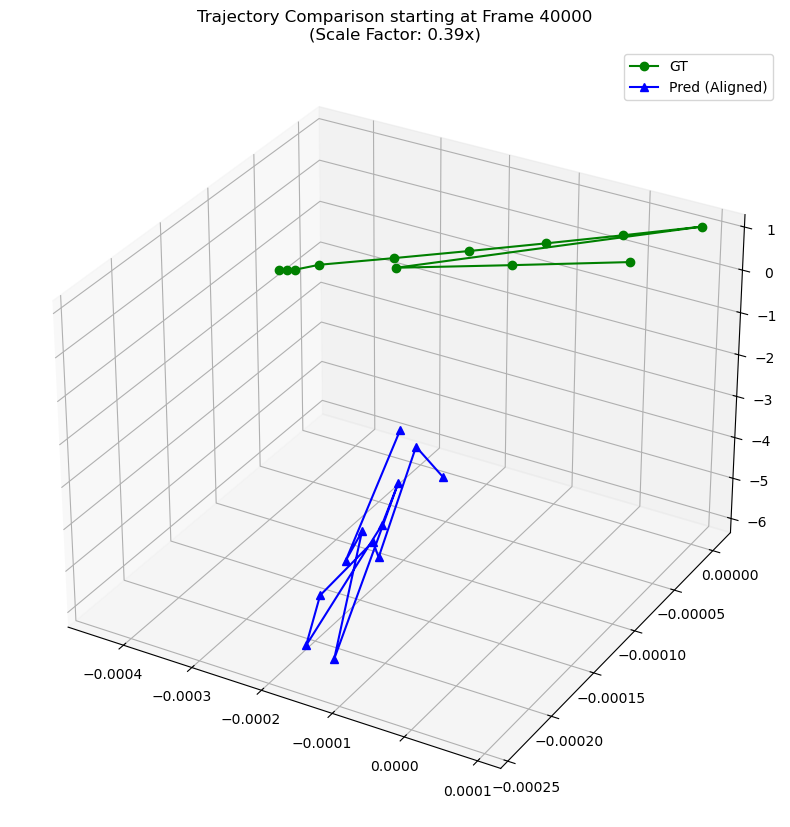

In [15]:
def extract_extrinsics_from_pose_enc(pose_enc, device):
    B, S, _ = pose_enc.shape
    T = pose_enc[..., :3]
    q = torch.nn.functional.normalize(pose_enc[..., 3:7], p=2, dim=-1)
    qx, qy, qz, qw = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    R = torch.stack([
        torch.stack([1 - 2*(qy**2 + qz**2), 2*(qx*qy - qw*qz), 2*(qx*qz + qw*qy)], dim=-1),
        torch.stack([2*(qx*qy + qw*qz), 1 - 2*(qx**2 + qz**2), 2*(qy*qz - qw*qx)], dim=-1),
        torch.stack([2*(qx*qz - qw*qy), 2*(qy*qz + qw*qx), 1 - 2*(qx**2 + qy**2)], dim=-1)
    ], dim=-2)
    return torch.cat([R, T.unsqueeze(-1)], dim=-1)

# CHECKPOINT_PATH = "/home/tim/vggt-cubify/vggt/training/logs/vggt_ros_subset_7400_13000_high_fidelity_test7_fixed_poses/ckpts/checkpoint_5.pt"
# CHECKPOINT_PATH = "/home/tim/vggt-cubify/vggt/models/model.pt"
CHECKPOINT_PATH = "/home/tim/vggt-cubify/vggt/training/logs/vggt_ros_full_high_fidelity_finetune-LR-5/ckpts/checkpoint.pt"
model = VGGT(enable_camera=True, enable_depth=True)
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
model.load_state_dict(checkpoint['model'] if 'model' in checkpoint else checkpoint, strict=False)
model = model.to(device).eval()

images_tensor = torch.from_numpy(np.stack(batch['images'])).permute(0, 3, 1, 2).float() / 255.0
images_tensor = images_tensor.unsqueeze(0).to(device) 

with torch.no_grad():
    outputs = model(images=images_tensor)

pred_pose_enc = outputs['pose_enc'][0]
pred_T = pred_pose_enc[:, :3].cpu().numpy()
gt_T = np.stack([e[:3, 3] for e in batch['extrinsics']])
scale_factor = np.linalg.norm(gt_T, axis=1).mean() / (np.linalg.norm(pred_T, axis=1).mean() + 1e-6)

pred_extrinsics = extract_extrinsics_from_pose_enc(outputs['pose_enc'], device)[0].cpu().numpy()

def get_centers(extrinsics):
    centers = []
    for ext in extrinsics:
        m = np.eye(4); m[:3, :] = ext
        try: centers.append(np.linalg.inv(m)[:3, 3])
        except: centers.append([0,0,0])
    return np.array(centers)

gt_centers = get_centers(batch['extrinsics'])
pred_centers_aligned = get_centers(pred_extrinsics) * scale_factor

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot(gt_centers[:,0], gt_centers[:,1], gt_centers[:,2], 'g-o', label='GT')
ax.plot(pred_centers_aligned[:,0], pred_centers_aligned[:,1], pred_centers_aligned[:,2], 'b-^', label='Pred (Aligned)')
ax.set_title(f"Trajectory Comparison starting at Frame {start_idx}\n(Scale Factor: {scale_factor:.2f}x)")
plt.legend()
plt.show()

## 3. Image and Depth Visualization

Let's look at the actual images and compare GT vs Predicted depth maps.

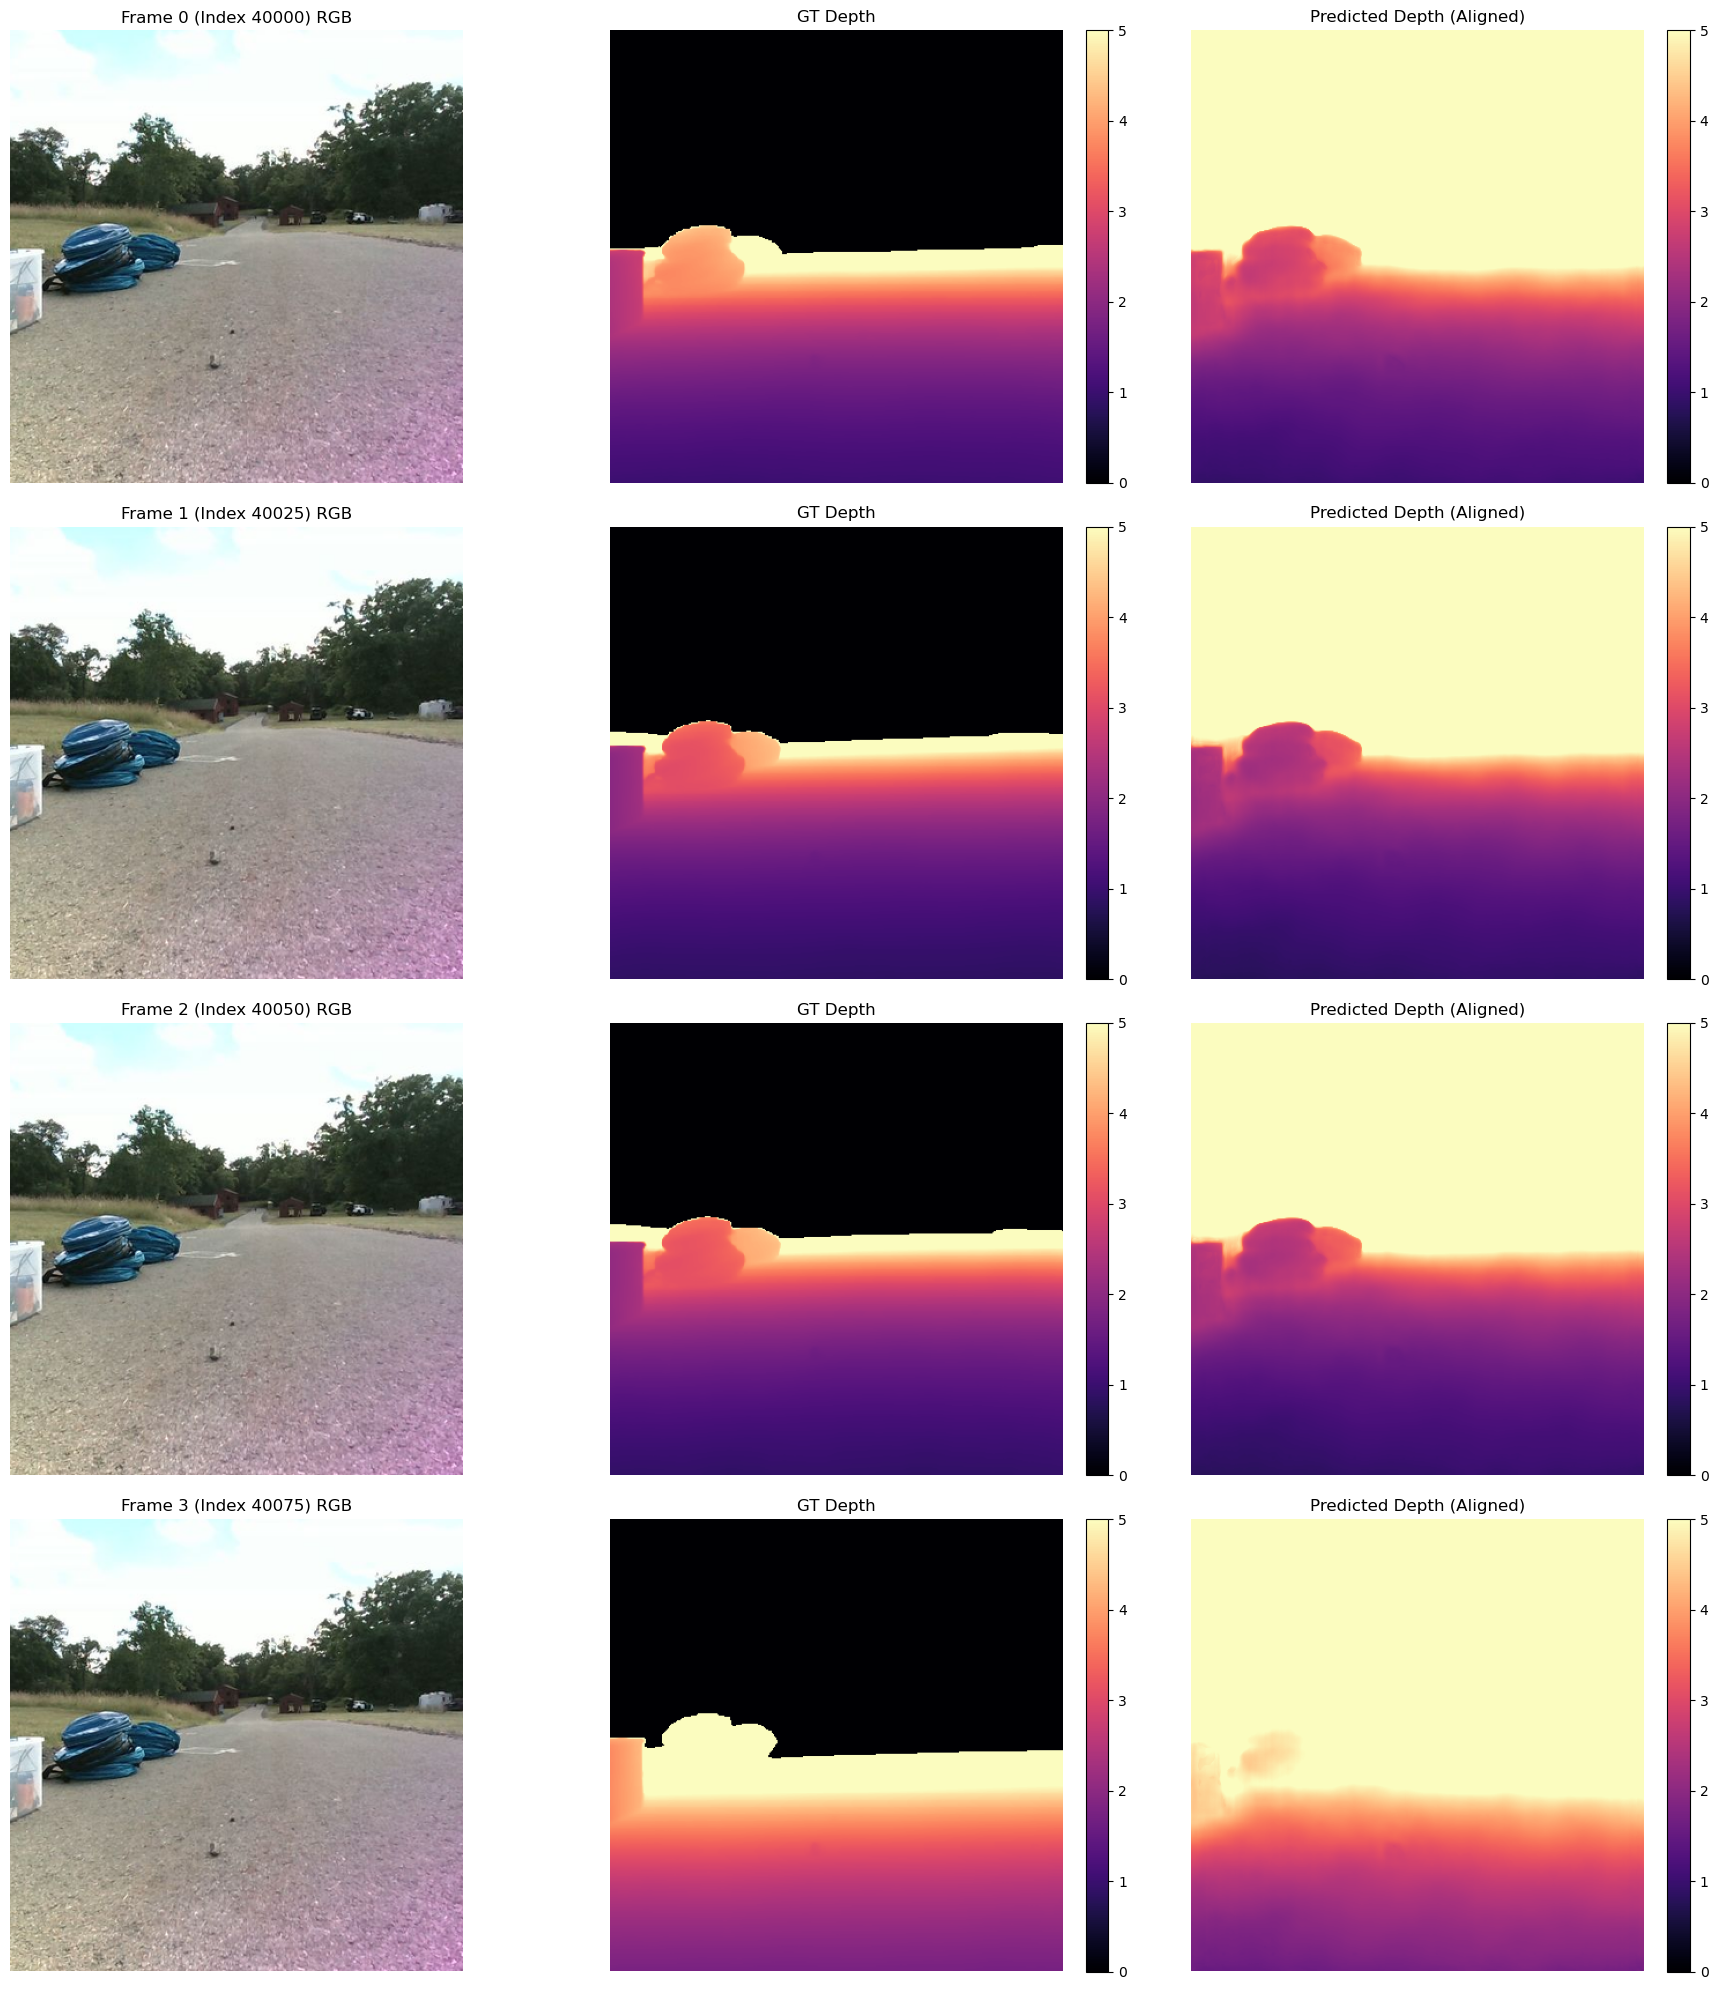

In [16]:
from matplotlib.colors import LogNorm

# Sample a few frames to visualize (e.g., first 4)
num_vis = min(4, len(batch['images']))
pred_depths = outputs['depth'].squeeze(1).cpu().numpy() # [B, S, H, W] -> [S, H, W]

fig, axes = plt.subplots(num_vis, 3, figsize=(18, 5 * num_vis))
if num_vis == 1:
    axes = [axes]

for i in range(num_vis):
    # RGB Image
    img = batch['images'][i]
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"Frame {i} (Index {batch['ids'][i]}) RGB")
    axes[i][0].axis('off')
    
    # GT Depth
    gt_depth = batch['depths'][i]
    im1 = axes[i][1].imshow(gt_depth, cmap='magma', vmin=0, vmax=5)
    axes[i][1].set_title(f"GT Depth")
    axes[i][1].axis('off')
    plt.colorbar(im1, ax=axes[i][1], fraction=0.046, pad=0.04)
    
    # Predicted Depth (Rescaled to GT for comparison)
    pred_depth = pred_depths[0, i]
    
    # Align pred depth to GT for visualization
    mask = (gt_depth > 0)
    if mask.sum() > 0:
        scale = np.median(gt_depth[mask]) / (np.median(pred_depth[mask]) + 1e-6)
        pred_depth_aligned = pred_depth * scale
    else:
        pred_depth_aligned = pred_depth
        
    im2 = axes[i][2].imshow(pred_depth_aligned, cmap='magma', vmin=0, vmax=5)
    axes[i][2].set_title(f"Predicted Depth (Aligned)")
    axes[i][2].axis('off')
    plt.colorbar(im2, ax=axes[i][2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

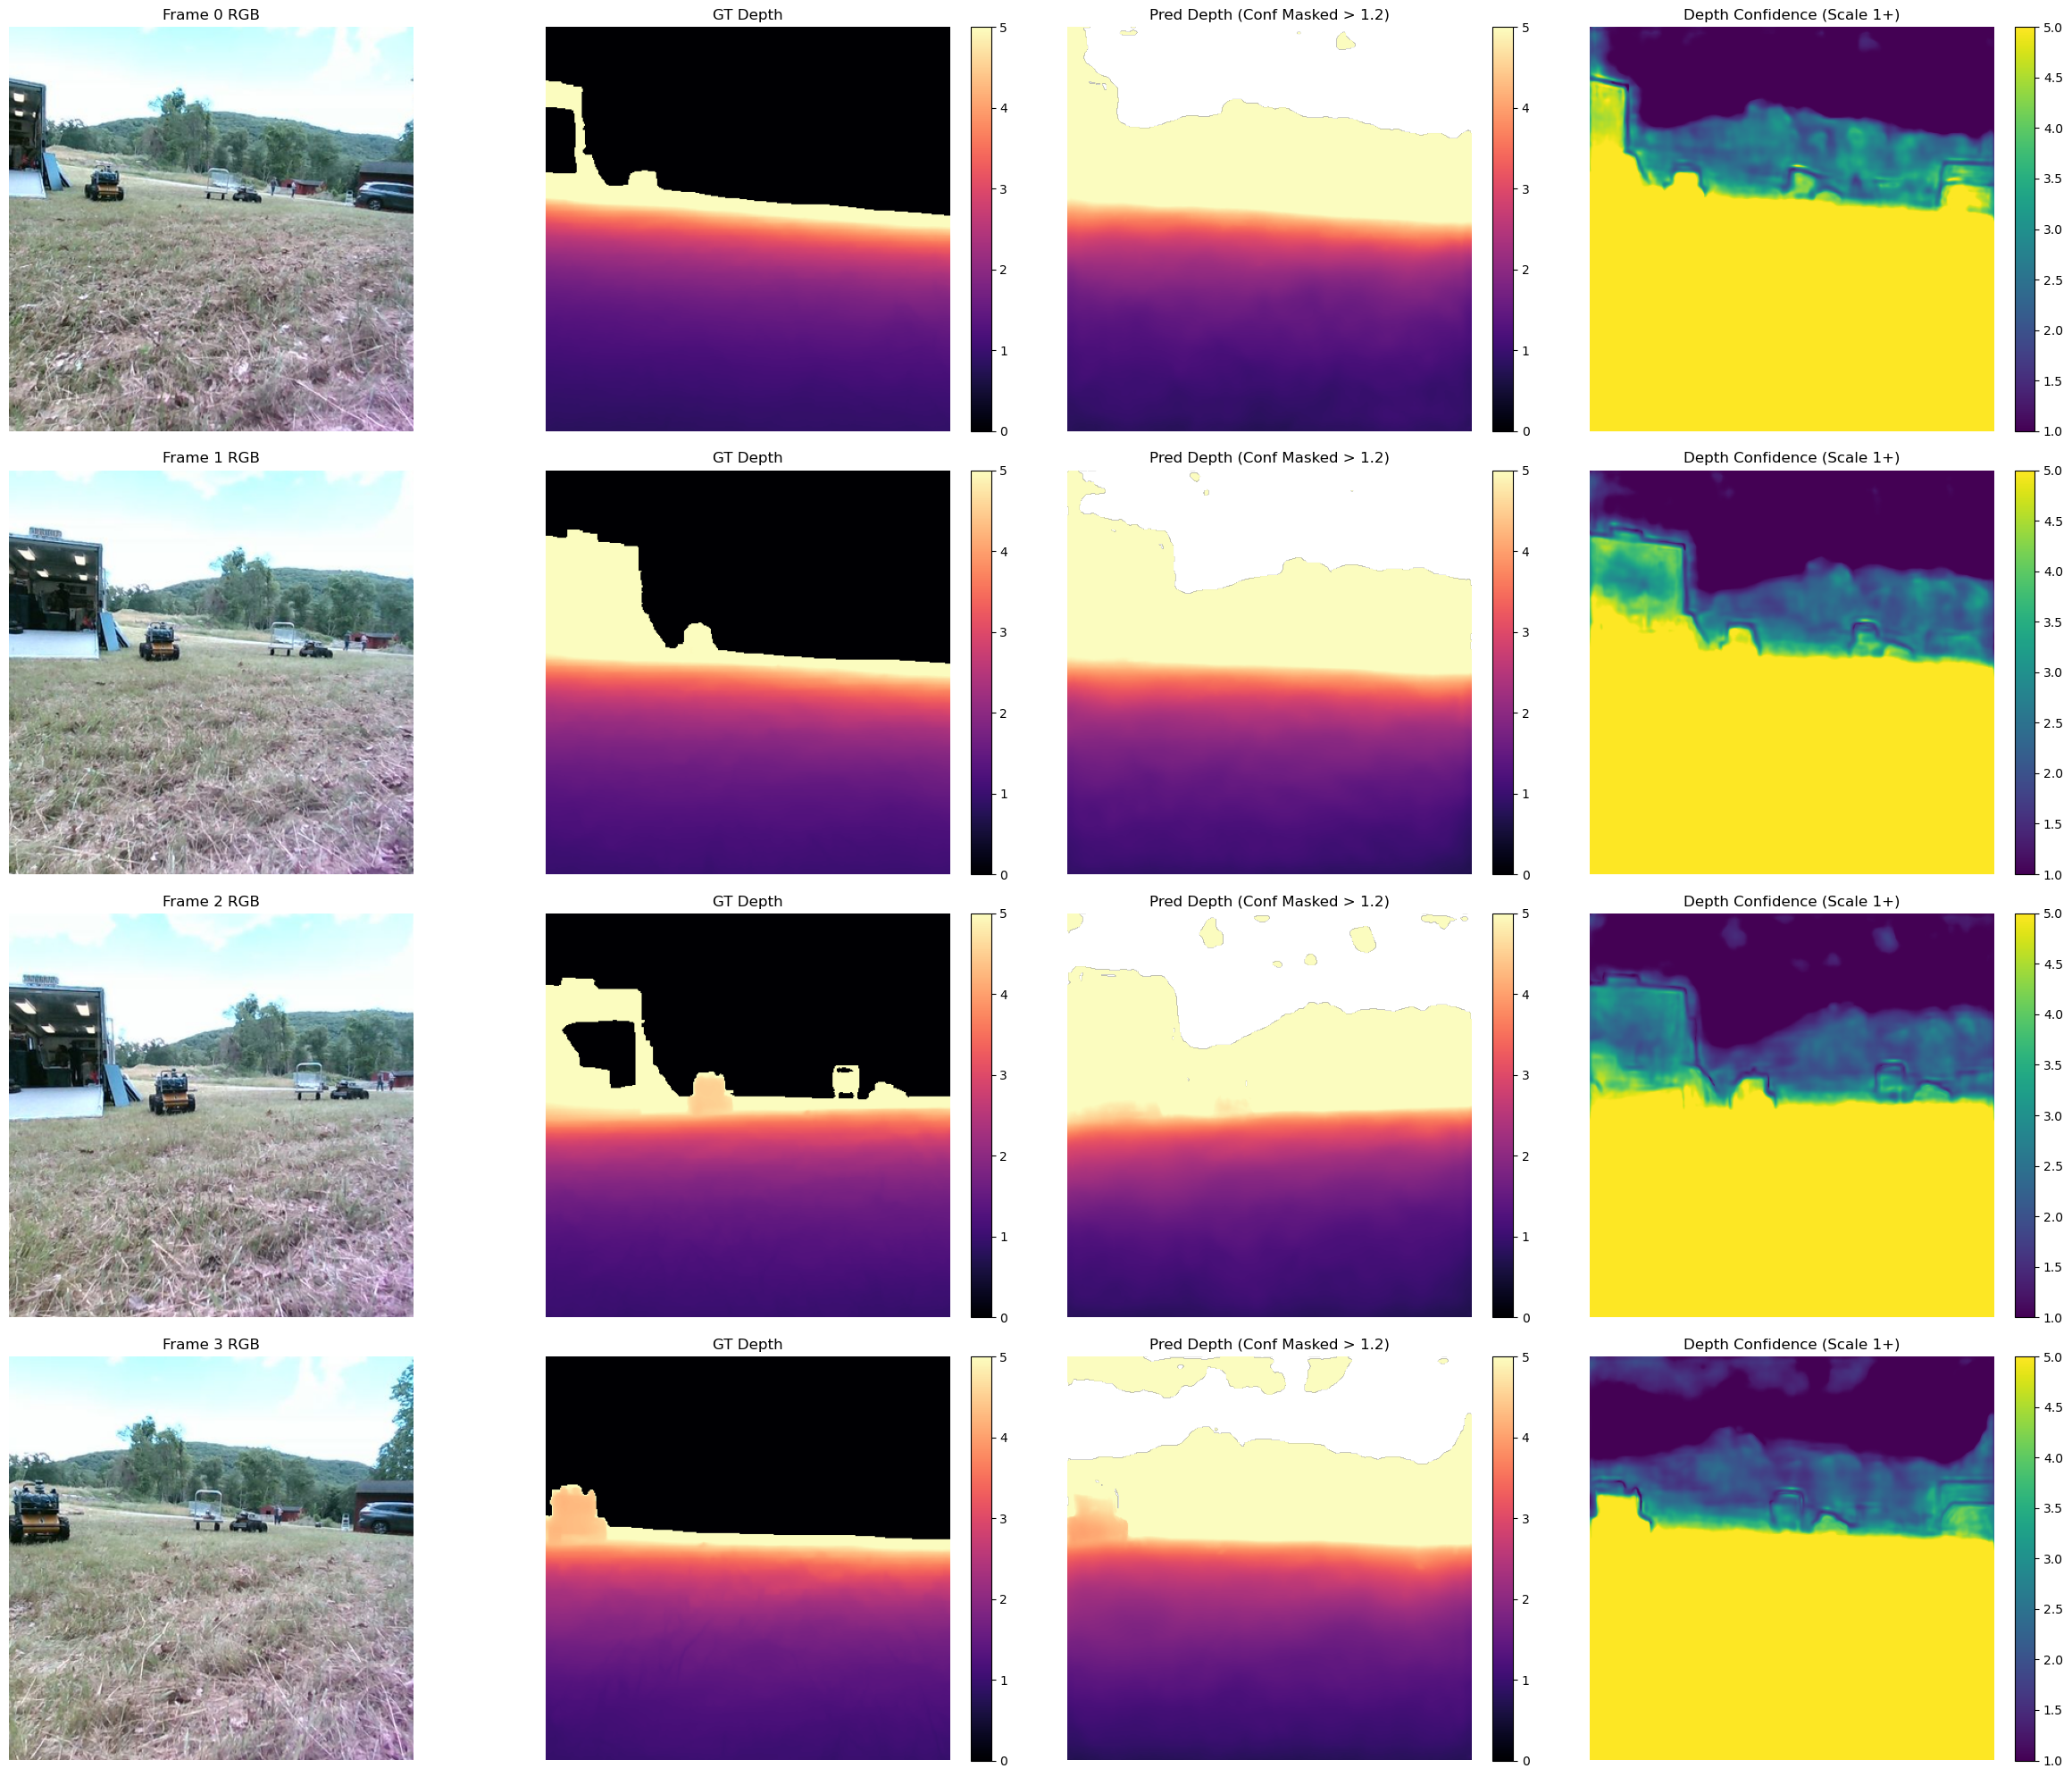

In [40]:
from matplotlib.colors import LogNorm

# Sample a few frames to visualize
num_vis = min(4, len(batch['images']))
# Confidence threshold: 1.0 is min, 2.0 is neutral. 
# Try 1.2 or 1.5 to start masking uncertain areas.
CONF_THRESHOLD = 1.2 

# 4 columns: RGB, GT Depth, Predicted Depth (Masked), Confidence
fig, axes = plt.subplots(num_vis, 4, figsize=(24, 5 * num_vis))
if num_vis == 1:
    axes = [axes]

for i in range(num_vis):
    # 1. RGB Image
    img = batch['images'][i]
    axes[i][0].imshow(img)
    axes[i][0].set_title(f"Frame {i} RGB")
    axes[i][0].axis('off')
    
    # 2. GT Depth
    gt_depth = batch['depths'][i]
    im1 = axes[i][1].imshow(gt_depth, cmap='magma', vmin=0, vmax=5)
    axes[i][1].set_title(f"GT Depth")
    axes[i][1].axis('off')
    plt.colorbar(im1, ax=axes[i][1], fraction=0.046, pad=0.04)
    
    # 3. Predicted Depth with Confidence Masking
    pred_depth = outputs['depth'][0, i].squeeze(-1).cpu().numpy()
    pred_conf = outputs['depth_conf'][0, i].cpu().numpy()
    
    # Align pred depth to GT for visualization
    mask_gt = (gt_depth > 0)
    if mask_gt.sum() > 0:
        scale = np.median(gt_depth[mask_gt]) / (np.median(pred_depth[mask_gt]) + 1e-6)
        pred_depth_aligned = pred_depth * scale
    else:
        pred_depth_aligned = pred_depth
        
    # Apply Confidence Mask
    # Areas with confidence below threshold are set to NaN (will appear as background)
    pred_depth_masked = pred_depth_aligned.copy()
    pred_depth_masked[pred_conf < CONF_THRESHOLD] = np.nan
    
    im2 = axes[i][2].imshow(pred_depth_masked, cmap='magma', vmin=0, vmax=5)
    axes[i][2].set_title(f"Pred Depth (Conf Masked > {CONF_THRESHOLD})")
    axes[i][2].axis('off')
    plt.colorbar(im2, ax=axes[i][2], fraction=0.046, pad=0.04)

    # 4. Confidence Map
    im3 = axes[i][3].imshow(pred_conf, cmap='viridis', vmin=1, vmax=5)
    axes[i][3].set_title(f"Depth Confidence (Scale 1+)")
    axes[i][3].axis('off')
    plt.colorbar(im3, ax=axes[i][3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


TypeError: get_camera_frustum() got an unexpected keyword argument 'color'

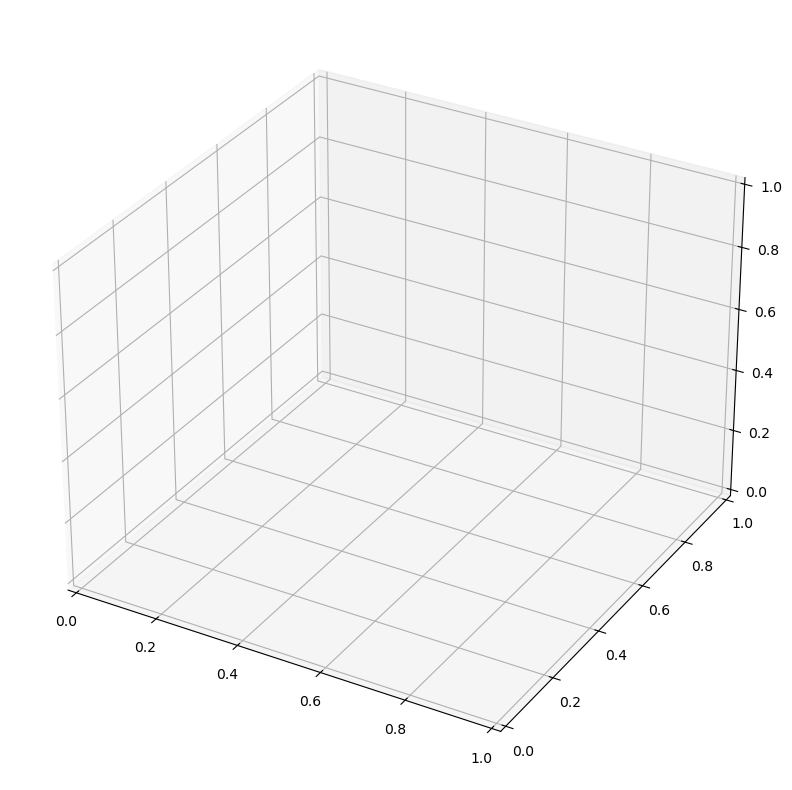

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from visualize_camera_poses import get_camera_frustum

def plot_precomputed_trajectory(npz_path, title="Pre-computed Trajectory"):
    data = np.load(npz_path)
    extrinsics = data['extrinsic']  # Shape: (N, 4, 4)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get camera centers
    centers = []
    for i in range(len(extrinsics)):
        # Transform is World -> Camera, so center is -R^T * t
        R = extrinsics[i, :3, :3]
        t = extrinsics[i, :3, 3]
        center = -R.T @ t
        centers.append(center)
        
        # Plot frustum for every Nth frame
        if i % (max(1, len(extrinsics)//10)) == 0:
            frustum = get_camera_frustum(extrinsics[i], color='blue', scale=0.1)
            for line in frustum:
                ax.plot(line[:, 0], line[:, 1], line[:, 2], color='blue', alpha=0.3)

    centers = np.array(centers)
    ax.plot(centers[:, 0], centers[:, 1], centers[:, 2], color='blue', label='Predicted Path', linewidth=2)
    ax.scatter(centers[0, 0], centers[0, 1], centers[0, 2], color='red', s=100, label='Start')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    # Set equal aspect ratio
    max_range = np.array([centers[:, 0].max()-centers[:, 0].min(), 
                         centers[:, 1].max()-centers[:, 1].min(), 
                         centers[:, 2].max()-centers[:, 2].min()]).max() / 2.0
    mid_x = (centers[:, 0].max()+centers[:, 0].min()) * 0.5
    mid_y = (centers[:, 1].max()+centers[:, 1].min()) * 0.5
    mid_z = (centers[:, 2].max()+centers[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.show()

npz_path = "/home/tim/vggt-cubify/vggt/input_images_20251003_155503_116770/predictions.npz"
plot_precomputed_trajectory(npz_path, title="Trajectory from 20251003_155503_116770")

## 3. Pre-computed Trajectory Visualization

This section visualizes the trajectory from a pre-computed `predictions.npz` file found in a specific run folder.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from visualize_camera_poses import get_camera_frustum

def plot_precomputed_trajectory(npz_path, title="Pre-computed Trajectory"):
    data = np.load(npz_path)
    extrinsics = data['extrinsic']  # Shape: (N, 4, 4)
    intrinsics = data['intrinsic']  # Shape: (N, 3, 3)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Get camera centers
    centers = []
    for i in range(len(extrinsics)):
        # Transform is World -> Camera, so center is -R^T * t
        R = extrinsics[i, :3, :3]
        t = extrinsics[i, :3, 3]
        center = -R.T @ t
        centers.append(center)
        
        # Plot frustum for every Nth frame
        if i % (max(1, len(extrinsics)//10)) == 0:
            # get_camera_frustum expects (3x4 extrinsic, 3x3 intrinsic)
            frustum = get_camera_frustum(extrinsics[i, :3, :], intrinsics[i], scale=0.1)
            # Plot the frustum lines (frustum is 5x3: center + 4 corners)
            for j in range(1, 5):
                # Line from center (0) to corner
                ax.plot([frustum[0,0], frustum[j,0]], [frustum[0,1], frustum[j,1]], [frustum[0,2], frustum[j,2]], color='blue', alpha=0.3)
                # Line from corner to next corner
                next_j = j % 4 + 1
                ax.plot([frustum[j,0], frustum[next_j,0]], [frustum[j,1], frustum[next_j,1]], [frustum[j,2], frustum[next_j,2]], color='blue', alpha=0.3)

    centers = np.array(centers)
    ax.plot(centers[:, 0], centers[:, 1], centers[:, 2], color='blue', label='Predicted Path', linewidth=2)
    ax.scatter(centers[0, 0], centers[0, 1], centers[0, 2], color='red', s=100, label='Start')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    # Set equal aspect ratio
    max_range = np.array([centers[:, 0].max()-centers[:, 0].min(), 
                         centers[:, 1].max()-centers[:, 1].min(), 
                         centers[:, 2].max()-centers[:, 2].min()]).max() / 2.0
    mid_x = (centers[:, 0].max()+centers[:, 0].min()) * 0.5
    mid_y = (centers[:, 1].max()+centers[:, 1].min()) * 0.5
    mid_z = (centers[:, 2].max()+centers[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.show()

npz_path = "/home/tim/vggt-cubify/vggt/input_images_20251003_155503_116770/predictions.npz"
plot_precomputed_trajectory(npz_path, title="Trajectory from 20251003_155503_116770")

## 3. Current vs. Saved Prediction Comparison

This section compares the live predictions from the currently loaded model against the saved predictions in `/home/tim/vggt-cubify/vggt/input_images_20251003_155503_116770/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.transforms import ToTensor

def compare_live_with_saved(run_dir, model, device):
    # 1. Load Saved Predictions
    npz_path = os.path.join(run_dir, "predictions.npz")
    saved_data = np.load(npz_path)
    # Saved extrinsic is usually 4x4. We want camera center for trajectory.
    saved_extrinsics = saved_data['extrinsic']
    
    # 2. Load Images and Run Live Inference
    img_dir = os.path.join(run_dir, "images")
    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])
    
    input_imgs = []
    for f in img_files:
        img = Image.open(os.path.join(img_dir, f)).convert('RGB')
        img = img.resize((392, 392))
        input_imgs.append(ToTensor()(img))
    
    batch_imgs = torch.stack(input_imgs).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Use model() instead of model.inference()
        pred = model(images=batch_imgs)
    
    # Live prediction pose_enc is [B, S, 9]. First 3 are translation T.
    live_pose_enc = pred['pose_enc'][0].cpu().numpy()
    live_T = live_pose_enc[:, :3]
    
    live_depths = pred['depth'][0].cpu().numpy()
    saved_depths = saved_data['depth']
    
    # 3. Visualize Trajectories
    fig = plt.figure(figsize=(15, 10))
    ax_traj = fig.add_subplot(121, projection='3d')
    
    def get_saved_centers(ext):
        centers = []
        for i in range(len(ext)):
            # Transform is World -> Camera, so center is -R^T * t
            R = ext[i, :3, :3]
            t = ext[i, :3, 3]
            centers.append(-R.T @ t)
        return np.array(centers)
    

    
    saved_centers = get_saved_centers(saved_extrinsics)
    
    # Plot trajectories
    # Note: live_T is often in a different scale/coordinate system than saved_extrinsics
    # We scale live_T to match saved_centers for visualization if needed.
    scale_factor = np.linalg.norm(saved_centers, axis=1).mean() / (np.linalg.norm(live_T, axis=1).mean() + 1e-6)
    live_T_scaled = live_T * scale_factor
    
    ax_traj.plot(saved_centers[:, 0], saved_centers[:, 1], saved_centers[:, 2], color='red', label='Saved Output Prediction', linewidth=2, linestyle='--')
    ax_traj.plot(live_T_scaled[:, 0], live_T_scaled[:, 1], live_T_scaled[:, 2], color='blue', label='Current Model Prediction (Scaled)', linewidth=3)
    
    ax_traj.scatter(saved_centers[0, 0], saved_centers[0, 1], saved_centers[0, 2], color='black', s=100, label='Start')
    ax_traj.set_title("Trajectory Comparison (Directional Check)")
    ax_traj.legend()
    
    # 4. Visualize Depth Comparison (Frame 0)
    ax_saved_depth = fig.add_subplot(222)
    im1 = ax_saved_depth.imshow(saved_depths[0].squeeze(), cmap='jet')
    ax_saved_depth.set_title("Saved Depth (Frame 0)")
    plt.colorbar(im1, ax=ax_saved_depth)
    
    ax_live_depth = fig.add_subplot(224)
    im2 = ax_live_depth.imshow(live_depths[0].squeeze(), cmap='jet')
    ax_live_depth.set_title("Current Model Depth (Frame 0)")
    plt.colorbar(im2, ax=ax_live_depth)
    
    plt.tight_layout()
    plt.show()

run_dir = "/home/tim/vggt-cubify/vggt/input_images_20251003_155503_116770"
if 'model' in globals():
    compare_live_with_saved(run_dir, model, device)
else:
    print("ERROR: Model not found. Please run the model loading cell first.")

ERROR: Model not found. Please run the model loading cell first.
